# House Price Regression — Phase 3: Modelling & Regularisation
Ames Housing Dataset

In [3]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load Data

df = pd.read_csv("train_processed.csv")

# Set up MLR 
X = df.drop(columns=["LogSalePrice"])
y = df["LogSalePrice"]
 
print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Features: 233  |  Samples: 2930
Train: 2344  |  Test: 586


# DEFINING MODELS

In [5]:
# Alphas to search over for regularised models
ALPHAS = np.logspace(-4, 4, 100)

SEED = 42
 
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RidgeCV(alphas=ALPHAS, cv=5))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LassoCV(alphas=ALPHAS, cv=5, max_iter=10000, random_state=SEED))
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  ElasticNetCV(alphas=ALPHAS, l1_ratio=[.1,.5,.7,.9,.95,1],
                                cv=5, max_iter=10000, random_state=SEED))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05,
            max_depth=4, subsample=0.8, random_state=SEED
        ))
    ]),
}

# TRAIN AND EVALUATE

In [6]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
 
def dollar_error(log_rmse):
    """Convert log-scale RMSE back to approximate dollar error."""
    return np.expm1(log_rmse)
 
results = {}
 
print("\nTraining models...\n")
 
for name, pipe in models.items():
    # 5-fold cross-validation on training set (negative RMSE → flip sign)
    cv_scores = cross_val_score(pipe, X_train, y_train,
                                cv=5, scoring="neg_root_mean_squared_error")
    cv_rmse = -cv_scores.mean()
    cv_std  = cv_scores.std()
 
    # Fit on full training set, evaluate on held-out test set
    pipe.fit(X_train, y_train)
    y_pred_test = pipe.predict(X_test)
 
    test_rmse = rmse(y_test, y_pred_test)
    test_r2   = r2_score(y_test, y_pred_test)
    overfit   = cv_rmse - test_rmse   # negative = worse on CV than test (fine)
 
    results[name] = {
        "CV RMSE (log)"  : round(cv_rmse, 5),
        "CV Std"         : round(cv_std,  5),
        "Test RMSE (log)": round(test_rmse, 5),
        "Test R²"        : round(test_r2, 4),
        "~$ Error"       : f"${dollar_error(test_rmse):,.0f}",
        "Overfit gap"    : round(overfit, 5),
    }
 
    print(f"  {name:<22}  CV RMSE={cv_rmse:.4f} ± {cv_std:.4f}  "
          f"Test RMSE={test_rmse:.4f}  R²={test_r2:.4f}  "
          f"≈ ${dollar_error(test_rmse):,.0f}")


Training models...

  Linear Regression       CV RMSE=0.1743 ± 0.0195  Test RMSE=0.1611  R²=0.8597  ≈ $0
  Ridge                   CV RMSE=0.1443 ± 0.0156  Test RMSE=0.1261  R²=0.9141  ≈ $0
  Lasso                   CV RMSE=0.1415 ± 0.0169  Test RMSE=0.1273  R²=0.9124  ≈ $0
  ElasticNet              CV RMSE=0.1415 ± 0.0163  Test RMSE=0.1264  R²=0.9137  ≈ $0
  Gradient Boosting       CV RMSE=0.1266 ± 0.0093  Test RMSE=0.1049  R²=0.9405  ≈ $0


# COMPARISON APPLIED MODELS

In [7]:
# COMPARISON TABLE


 
results_df = pd.DataFrame(results).T.sort_values("Test RMSE (log)")
 
print("\n" + "=" * 70)
print("MODEL COMPARISON TABLE  (sorted by Test RMSE)")
print("=" * 70)
print(results_df.to_string())
 
best_model_name = results_df.index[0]
best_pipe       = models[best_model_name]
print(f"\n✓ Best model: {best_model_name}")
 
# ── Regularisation info for penalised models
for name, pipe in models.items():
    m = pipe.named_steps["model"]
    if hasattr(m, "alpha_"):
        print(f"  {name} best alpha: {m.alpha_:.5f}")
    if hasattr(m, "l1_ratio_"):
        print(f"  {name} best l1_ratio: {m.l1_ratio_:.3f}")
 
# Lasso: how many features were zeroed out?
lasso_model = models["Lasso"].named_steps["model"]
n_zero = np.sum(lasso_model.coef_ == 0)
print(f"\n  Lasso zeroed out {n_zero} / {len(lasso_model.coef_)} features "
      f"({n_zero/len(lasso_model.coef_)*100:.1f}%) — built-in feature selection")


MODEL COMPARISON TABLE  (sorted by Test RMSE)
                  CV RMSE (log)   CV Std Test RMSE (log) Test R² ~$ Error Overfit gap
Gradient Boosting       0.12656  0.00927          0.1049  0.9405       $0     0.02166
Ridge                   0.14425  0.01562         0.12605  0.9141       $0      0.0182
ElasticNet              0.14147  0.01634         0.12638  0.9137       $0     0.01509
Lasso                   0.14155  0.01689         0.12732  0.9124       $0     0.01422
Linear Regression       0.17429   0.0195         0.16113  0.8597       $0     0.01316

✓ Best model: Gradient Boosting
  Ridge best alpha: 351.11917
  Lasso best alpha: 0.00285
  ElasticNet best alpha: 0.02656
  ElasticNet best l1_ratio: 0.100

  Lasso zeroed out 131 / 233 features (56.2%) — built-in feature selection


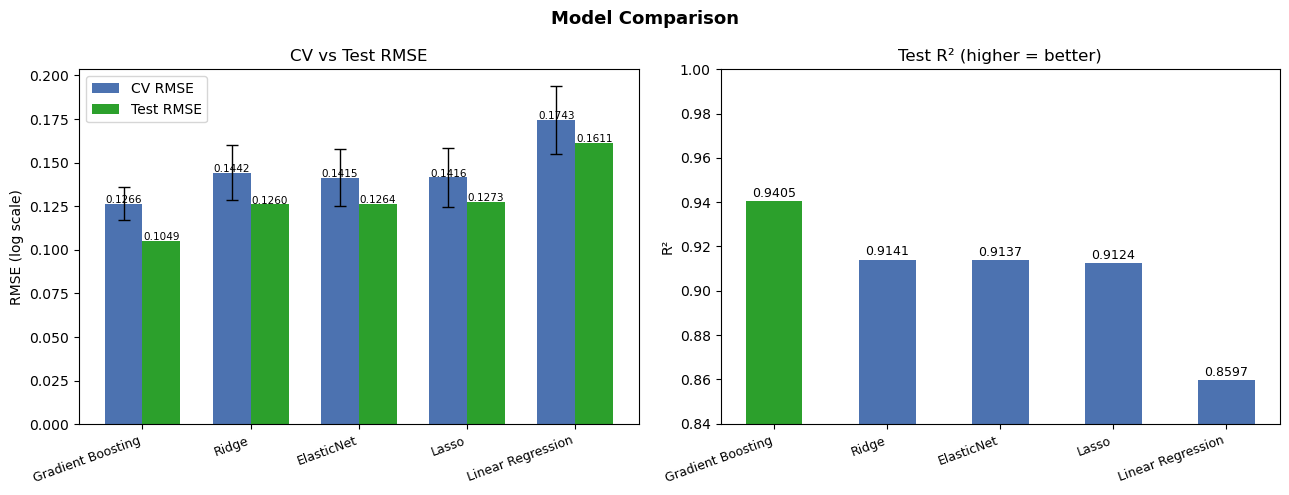

In [8]:
# BAR CHART — MODEL COMPARISON

 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Comparison", fontweight="bold", fontsize=13)
 
names    = results_df.index.tolist()
cv_rmses = results_df["CV RMSE (log)"].astype(float).tolist()
cv_stds  = results_df["CV Std"].astype(float).tolist()
t_rmses  = results_df["Test RMSE (log)"].astype(float).tolist()
r2s      = results_df["Test R²"].astype(float).tolist()
 
# Panel 1: CV vs Test RMSE
x = np.arange(len(names))
w = 0.35
ax = axes[0]
ax.bar(x - w/2, cv_rmses, w, label="CV RMSE",   color="#4C72B0",
       yerr=cv_stds, capsize=4, error_kw={"linewidth": 1})
ax.bar(x + w/2, t_rmses,  w, label="Test RMSE", color="#2ca02c")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("RMSE (log scale)")
ax.set_title("CV vs Test RMSE")
ax.legend()
# Annotate bars
for i, (cv, te) in enumerate(zip(cv_rmses, t_rmses)):
    ax.text(i - w/2, cv + 0.0005, f"{cv:.4f}", ha="center", fontsize=7.5)
    ax.text(i + w/2, te + 0.0005, f"{te:.4f}", ha="center", fontsize=7.5)
 
# Panel 2: R²
ax2 = axes[1]
bar_colors = ["#2ca02c" if v == max(r2s) else "#4C72B0" for v in r2s]
bars = ax2.bar(names, r2s, color=bar_colors, width=0.5)
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
ax2.set_ylabel("R²")
ax2.set_title("Test R² (higher = better)")
ax2.set_ylim(min(r2s) - 0.02, 1.0)
for bar, v in zip(bars, r2s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{v:.4f}", ha="center", fontsize=9)
 
plt.tight_layout()
plt.savefig("phase3_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()